<a href="https://colab.research.google.com/github/bodaprashanthi075/Blinkit-Business-Performance-Analysis/blob/main/notebooks/Blinkit_Business_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Blinkit Business Performance Analysis

## Business Analytics Project

This project analyzes Blinkit's business data to understand sales performance, customer behavior, product performance, delivery efficiency, and marketing performance using Python and Exploratory Data Analysis (EDA).

## 🎯 Problem Statement

Blinkit generates large amounts of sales and operational data every day. Understanding customer purchasing behavior, product demand, delivery performance, and marketing effectiveness can help improve business performance.

This project analyzes Blinkit's business data to identify important trends, patterns, and business insights.

## 📌 Project Objectives

- Analyze overall sales performance
- Understand customer purchasing behavior
- Identify top-performing products
- Analyze delivery performance
- Evaluate marketing performance
- Identify important business trends
- Provide data-driven business recommendations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

orders = pd.read_csv('/content/blinkit_orders.csv')

orders.head()

orders.shape

(5000, 10)

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='object')

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
promised_delivery_time,0
actual_delivery_time,0
delivery_status,0
order_total,0
payment_method,0
delivery_partner_id,0
store_id,0


In [ ]:
orders.duplicated().sum()

np.int64(0)

In [ ]:
orders.dtypes

,0
order_id,int64
customer_id,int64
order_date,object
promised_delivery_time,object
actual_delivery_time,object
delivery_status,object
order_total,float64
payment_method,object
delivery_partner_id,int64
store_id,int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

project_folder = "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created!")

Project folder created!


In [ ]:
import shutil

shutil.copy(
    "/content/blinkit_orders.csv",
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_orders.csv"
)

print("blinkit_orders.csv saved to Google Drive!")

blinkit_orders.csv saved to Google Drive!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Classroom', 'resume (1).pdf', 'resume.pdf', 'PRIYANKA.RESUME (1).pdf', 'BodaPriyanka_Netflix Data Analysis Project PPT.pptx', 'resume.gdoc', 'bodaprashanthi075@gmail (3).com.jpeg', 'bodaprashanthi075@gmail (2).com.jpeg', 'bodaprashanthi075@gmail (1).com.jpeg', '23NN1A05C1.jpeg', 'bodaprashanthi075@gmail.com.jpeg', 'IMG-20260811-WA0042.jpg', 'survey Papers.zip', 'Brain_Tumor_Project', 'Blinkit_Business_Performance_Analysis']


In [8]:
import os

print(os.listdir("/content/drive/MyDrive/Blinkit_Business_Performance_Analysis"))

['blinkit_orders.csv']


In [9]:
import pandas as pd

orders = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_orders.csv"
)

orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [10]:
orders[['order_date', 'promised_delivery_time', 'actual_delivery_time']].head()

,order_date,promised_delivery_time,actual_delivery_time
0,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01
1,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29
2,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12
3,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56
4,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39


In [12]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

In [13]:
orders.dtypes

,0
order_id,int64
customer_id,int64
order_date,datetime64[ns]
promised_delivery_time,datetime64[ns]
actual_delivery_time,datetime64[ns]
delivery_status,object
order_total,float64
payment_method,object
delivery_partner_id,int64
store_id,int64


In [14]:
orders.describe()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,order_total,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000,5000,5000,5000.00000,5000.000000,5000.000000
mean,5.029129e+09,5.009685e+07,2024-01-09 00:36:06.259200,2024-01-09 00:51:05.743200256,2024-01-09 00:55:32.323200,2201.86170,50050.318200,4999.689000
min,6.046500e+04,3.181300e+04,2023-03-16 08:10:44,2023-03-16 08:27:44,2023-03-16 08:24:44,13.25000,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,2023-08-17 01:54:09.249999872,2023-08-17 02:13:24.249999872,2023-08-17 02:27:24.249999872,1086.21500,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,2024-01-07 11:35:32,2024-01-07 11:47:02,2024-01-07 11:51:02,2100.69000,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,2024-06-03 20:53:15.750000128,2024-06-03 21:09:30.750000128,2024-06-03 21:09:30.750000128,3156.88250,74478.250000,7500.750000
max,9.998298e+09,9.989390e+07,2024-11-04 20:29:15,2024-11-04 20:43:15,2024-11-04 20:47:15,6721.46000,99968.000000,9995.000000
std,2.863533e+09,2.919082e+07,NaN,NaN,NaN,1303.02438,28802.276922,2886.089242


In [15]:
orders['delivery_status'].value_counts()

,count
delivery_status,
On Time,3470
Slightly Delayed,1037
Significantly Delayed,493


In [16]:
orders['payment_method'].value_counts()

,count
payment_method,
Card,1285
Cash,1257
Wallet,1244
UPI,1214


In [17]:
orders['order_total'].sum()

np.float64(11009308.5)

In [18]:
orders['customer_id'].nunique()

2172

In [19]:
orders['order_total'].mean()

np.float64(2201.8617)

In [20]:
orders['customer_id'].value_counts().value_counts().sort_index()

,count
count,
1,680
2,686
3,451
4,234
5,82
6,28
7,8
8,2
9,1


In [21]:
order_items = pd.read_csv('/content/blinkit_order_items.csv')

order_items.head()

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [22]:
order_items.shape

(5000, 4)

In [23]:
order_items.isnull().sum()

,0
order_id,0
product_id,0
quantity,0
unit_price,0


In [24]:
order_items.duplicated().sum()

np.int64(0)

In [25]:
order_items.dtypes

,0
order_id,int64
product_id,int64
quantity,int64
unit_price,float64


In [26]:
order_items.describe()

,order_id,product_id,quantity,unit_price
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,5.029129e+09,509974.939600,2.006800,493.157900
std,2.863533e+09,293678.307475,0.820542,298.075647
min,6.046500e+04,4452.000000,1.000000,12.320000
25%,2.531421e+09,257719.000000,1.000000,227.220000
50%,5.074378e+09,540618.000000,2.000000,448.160000
75%,7.488579e+09,747801.000000,3.000000,781.080000
max,9.998298e+09,993331.000000,3.000000,995.980000


In [27]:
order_items['product_id'].nunique()

268

In [28]:
order_items['quantity'].sum()

np.int64(10034)

In [29]:
order_items['order_id'].nunique()

5000

In [30]:
(order_items['quantity'] * order_items['unit_price']).sum()

np.float64(4972415.43)

In [31]:
order_items['unit_price'].mean()

np.float64(493.1579)

In [32]:
order_items['product_id'].value_counts().head(10)

,count
product_id,
51036,34
820973,33
880510,29
131748,29
34186,29
992178,29
89084,28
654623,28
604184,28


In [33]:
order_items.groupby('product_id')['quantity'].sum().sort_values(ascending=False).head(10)

,quantity
product_id,
51036,70
820973,68
604184,62
34186,61
992178,60
880510,58
673058,56
89084,56
123983,55


In [34]:
order_items['item_sales'] = order_items['quantity'] * order_items['unit_price']

order_items.groupby('product_id')['item_sales'].sum().sort_values(ascending=False).head(10)

,item_sales
product_id,
51036,65212.70
34186,56464.65
880510,55182.94
557908,51830.35
264803,51790.96
739534,48733.44
18035,46509.12
883013,45534.48
349294,44868.00


In [35]:
order_items.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_order_items_analyzed.csv",
    index=False
)

print("Analyzed order_items dataset saved to Google Drive!")

Analyzed order_items dataset saved to Google Drive!


In [36]:
products = pd.read_csv('/content/blinkit_products.csv')

products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [37]:
products.shape

(268, 10)

In [38]:
products.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
price,0
mrp,0
margin_percentage,0
shelf_life_days,0
min_stock_level,0
max_stock_level,0


In [39]:
products.duplicated().sum()

np.int64(0)

In [40]:
products['category'].value_counts()

,count
category,
Dairy & Breakfast,30
Fruits & Vegetables,27
Snacks & Munchies,27
Household Care,27
Pharmacy,25
Pet Care,25
Personal Care,25
Grocery & Staples,24
Cold Drinks & Juices,22


In [41]:
products['brand'].nunique()

267

In [42]:
products['brand'].value_counts().head()

,count
brand,
Jha Group,2
Munshi-Grewal,1
"Balan, Samra and Sekhon",1
"Kibe, Contractor and Randhawa",1
"Sampath, Mane and Mody",1


In [43]:
products['price'].mean()

np.float64(488.356828358209)

In [44]:
products['mrp'].mean()

np.float64(680.4347388059701)

In [45]:
products['margin_percentage'].mean()

np.float64(27.779850746268657)

In [46]:
products['shelf_life_days'].describe()

,shelf_life_days
count,268.000000
mean,231.757463
std,151.205830
min,3.000000
25%,90.000000
50%,365.000000
75%,365.000000
max,365.000000


In [47]:
products['min_stock_level'].describe()

,min_stock_level
count,268.000000
mean,20.388060
std,5.958546
min,10.000000
25%,15.000000
50%,21.000000
75%,25.250000
max,30.000000


In [48]:
products['max_stock_level'].describe()

,max_stock_level
count,268.000000
mean,74.753731
std,14.591535
min,50.000000
25%,63.750000
50%,73.000000
75%,88.000000
max,100.000000


In [49]:
products.groupby('category')['price'].mean().sort_values(ascending=False)

,price
category,
Pharmacy,599.026800
Dairy & Breakfast,569.096333
Pet Care,546.934000
Fruits & Vegetables,546.535185
Baby Care,516.152500
Cold Drinks & Juices,500.515000
Personal Care,441.595600
Instant & Frozen Food,420.345000
Snacks & Munchies,417.106667


In [50]:
products['category'].value_counts()

,count
category,
Dairy & Breakfast,30
Fruits & Vegetables,27
Snacks & Munchies,27
Household Care,27
Pharmacy,25
Pet Care,25
Personal Care,25
Grocery & Staples,24
Cold Drinks & Juices,22


In [51]:
products.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_products_analyzed.csv",
    index=False
)

print("Analyzed products dataset saved to Google Drive!")

Analyzed products dataset saved to Google Drive!


In [52]:
customers = pd.read_csv('/content/blinkit_customers.csv')
customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [53]:
customers.shape

(2500, 11)

In [54]:
customers.isnull().sum()

,0
customer_id,0
customer_name,0
email,0
phone,0
address,0
area,0
pincode,0
registration_date,0
customer_segment,0
total_orders,0


In [55]:
customers.duplicated().sum()

np.int64(0)

In [56]:
customers.dtypes

,0
customer_id,int64
customer_name,object
email,object
phone,int64
address,object
area,object
pincode,int64
registration_date,object
customer_segment,object
total_orders,int64


In [57]:
customers['registration_date'] = pd.to_datetime(customers['registration_date'])

In [58]:
customers.dtypes

,0
customer_id,int64
customer_name,object
email,object
phone,int64
address,object
area,object
pincode,int64
registration_date,datetime64[ns]
customer_segment,object
total_orders,int64


In [59]:
customers['customer_segment'].value_counts()

,count
customer_segment,
Regular,639
Premium,633
New,628
Inactive,600


In [60]:
customers['total_orders'].describe()

,total_orders
count,2500.000000
mean,10.491600
std,5.805533
min,1.000000
25%,6.000000
50%,10.000000
75%,16.000000
max,20.000000


In [61]:
customers['avg_order_value'].describe()

,avg_order_value
count,2500.000000
mean,1102.375836
std,523.043183
min,200.430000
25%,631.817500
50%,1118.650000
75%,1565.400000
max,1999.830000


In [62]:
customers['area'].nunique()

316

In [63]:
customers['area'].value_counts().head(10)

,count
area,
Jalna,18
Deoghar,17
Bathinda,17
Orai,17
Ratlam,16
Ghaziabad,16
Kishanganj,15
Kadapa,14
Nandyal,14


In [64]:
customers.groupby('customer_segment')['avg_order_value'].mean().sort_values(ascending=False)

,avg_order_value
customer_segment,
New,1116.635557
Inactive,1102.150000
Premium,1101.473965
Regular,1089.467042


In [65]:
customers.groupby('customer_segment')['total_orders'].sum().sort_values(ascending=False)

,total_orders
customer_segment,
New,6829
Regular,6598
Premium,6452
Inactive,6350


In [66]:
customers.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_customers_analyzed.csv",
    index=False
)

print("Analyzed customers dataset saved to Google Drive!")

Analyzed customers dataset saved to Google Drive!


In [67]:
delivery = pd.read_csv('/content/blinkit_delivery_performance.csv')
delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [68]:
delivery.shape

(5000, 8)

In [69]:
delivery.isnull().sum()

,0
order_id,0
delivery_partner_id,0
promised_time,0
actual_time,0
delivery_time_minutes,0
distance_km,0
delivery_status,0
reasons_if_delayed,1902


In [70]:
delivery.duplicated().sum()

np.int64(0)

In [71]:
delivery.dtypes

,0
order_id,int64
delivery_partner_id,int64
promised_time,object
actual_time,object
delivery_time_minutes,float64
distance_km,float64
delivery_status,object
reasons_if_delayed,object


In [72]:
delivery['promised_time'] = pd.to_datetime(delivery['promised_time'])
delivery['actual_time'] = pd.to_datetime(delivery['actual_time'])

In [73]:
delivery['delivery_status'].value_counts()

,count
delivery_status,
On Time,3470
Slightly Delayed,1037
Significantly Delayed,493


In [74]:
delivery['delivery_time_minutes'].describe()

,delivery_time_minutes
count,5000.000000
mean,4.443000
std,8.063929
min,-5.000000
25%,-1.000000
50%,2.000000
75%,8.000000
max,30.000000


In [75]:
delivery['distance_km'].describe()

,distance_km
count,5000.000000
mean,2.718048
std,1.290306
min,0.500000
25%,1.590000
50%,2.690000
75%,3.850000
max,5.000000


In [76]:
delivery['reasons_if_delayed'].value_counts()

,count
reasons_if_delayed,
Traffic,3098


In [77]:
delivery['delivery_partner_id'].nunique()

5000

In [78]:
delivery.groupby('delivery_status')['delivery_time_minutes'].mean()

,delivery_time_minutes
delivery_status,
On Time,0.013833
Significantly Delayed,22.843813
Slightly Delayed,10.515911


In [79]:
delivery.groupby('delivery_status')['distance_km'].mean()

,distance_km
delivery_status,
On Time,2.716441
Significantly Delayed,2.692515
Slightly Delayed,2.735564


In [80]:
delivery['delivery_status'].value_counts()

,count
delivery_status,
On Time,3470
Slightly Delayed,1037
Significantly Delayed,493


In [81]:
delivery.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_delivery_performance_analyzed.csv",
    index=False
)

print("Analyzed delivery dataset saved to Google Drive!")

Analyzed delivery dataset saved to Google Drive!


In [82]:
marketing = pd.read_csv('/content/blinkit_marketing_performance.csv')
marketing.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [83]:
marketing.shape

(5400, 11)

In [84]:
marketing.isnull().sum()

,0
campaign_id,0
campaign_name,0
date,0
target_audience,0
channel,0
impressions,0
clicks,0
conversions,0
spend,0
revenue_generated,0


In [85]:
marketing.duplicated().sum()

np.int64(0)

In [86]:
marketing.dtypes

,0
campaign_id,int64
campaign_name,object
date,object
target_audience,object
channel,object
impressions,int64
clicks,int64
conversions,int64
spend,float64
revenue_generated,float64


In [87]:
marketing['date'] = pd.to_datetime(marketing['date'])

In [88]:
marketing.describe()

,campaign_id,date,impressions,clicks,conversions,spend,revenue_generated,roas
count,5400.000000,5400,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000
mean,501315.219074,2024-01-10 12:00:00.000000256,5460.668519,550.767593,55.192222,3022.192267,5961.742106,2.740711
min,243.000000,2023-03-17 00:00:00,1002.000000,100.000000,10.000000,1000.630000,2003.100000,1.500000
25%,249200.000000,2023-08-13 18:00:00,3231.500000,322.000000,32.000000,2029.070000,3907.240000,2.120000
50%,505012.500000,2024-01-10 12:00:00,5457.500000,555.000000,55.000000,3042.485000,5935.940000,2.725000
75%,752219.250000,2024-06-08 06:00:00,7676.250000,772.000000,78.000000,4011.572500,7973.712500,3.370000
max,999950.000000,2024-11-05 00:00:00,9999.000000,1000.000000,100.000000,4997.550000,9999.540000,4.000000
std,287611.524258,NaN,2571.779820,260.080051,26.150173,1148.732680,2322.242911,0.722986


In [89]:
marketing['channel'].value_counts()

,count
channel,
App,1374
Email,1343
Social Media,1343
SMS,1340


In [90]:
marketing['target_audience'].value_counts()

,count
target_audience,
New Users,1356
Premium,1355
Inactive,1347
All,1342


In [91]:
marketing.groupby('channel')['roas'].mean().sort_values(ascending=False)

,roas
channel,
App,2.754301
Social Media,2.749188
Email,2.748861
SMS,2.710112


In [92]:
marketing['campaign_name'].value_counts()

,count
campaign_name,
New User Discount,600
Weekend Special,600
Festival Offer,600
Flash Sale,600
Membership Drive,600
Category Promotion,600
App Push Notification,600
Email Campaign,600
Referral Program,600


In [93]:
marketing.groupby('target_audience')['roas'].mean().sort_values(ascending=False)

,roas
target_audience,
All,2.766572
New Users,2.753370
Premium,2.742103
Inactive,2.700802


In [94]:
marketing.groupby('channel')[['spend', 'revenue_generated', 'conversions']].sum()

,spend,revenue_generated,conversions
channel,,,
App,4213378.75,8075010.49,75192
Email,3997488.04,8189331.58,74671
SMS,3998607.54,7938649.32,73235
Social Media,4110363.91,7990415.98,74940


In [95]:
marketing[['impressions', 'clicks', 'conversions', 'spend', 'revenue_generated']].sum()

,0
impressions,29487610.00
clicks,2974145.00
conversions,298038.00
spend,16319838.24
revenue_generated,32193407.37


In [96]:
marketing['revenue_generated'].sum() / marketing['spend'].sum()

np.float64(1.9726548080050088)

In [97]:
marketing.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_marketing_performance_analyzed.csv",
    index=False
)

print("Analyzed marketing dataset saved to Google Drive!")

Analyzed marketing dataset saved to Google Drive!


In [98]:
combined_sales = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

combined_sales.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,product_id,quantity,unit_price,item_sales
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,642612,3,517.03,1551.09
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,378676,1,881.42,881.42
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,741341,2,923.84,1847.68
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,561860,1,874.78,874.78
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,602241,2,976.55,1953.10


In [99]:
combined_sales.shape

(5000, 14)

In [100]:
combined_sales['order_id'].nunique()

5000

In [101]:
combined_sales['order_total'].sum()

np.float64(11009308.5)

In [102]:
order_items['item_sales'].sum()

np.float64(4972415.43)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
orders = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_orders.csv"
)

print("Orders dataset loaded!")

Orders dataset loaded!


In [7]:
order_items = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_order_items_analyzed.csv"
)

print("Order items dataset loaded!")

Order items dataset loaded!


In [8]:
combined_sales = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

print("Combined dataset recreated successfully!")

Combined dataset recreated successfully!


In [9]:
combined_sales['order_total'].sum() - order_items['item_sales'].sum()

np.float64(6036893.07)

In [10]:
combined_sales['order_total'].mean()

np.float64(2201.8617)

In [12]:
combined_sales['order_date'] = pd.to_datetime(combined_sales['order_date'])

print("order_date converted to datetime!")

order_date converted to datetime!


In [13]:
monthly_sales = combined_sales.groupby(
    combined_sales['order_date'].dt.to_period('M')
)['order_total'].sum()

monthly_sales

,order_total
order_date,
2023-03,272878.96
2023-04,554344.77
2023-05,608213.54
2023-06,505227.66
2023-07,567639.91
2023-08,623472.35
2023-09,571117.81
2023-10,578369.83
2023-11,567783.74


In [14]:
monthly_orders = combined_sales.groupby(
    combined_sales['order_date'].dt.to_period('M')
)['order_id'].nunique()

monthly_orders

,order_id
order_date,
2023-03,120
2023-04,238
2023-05,276
2023-06,232
2023-07,244
2023-08,285
2023-09,262
2023-10,254
2023-11,265


In [15]:
monthly_aov = monthly_sales / monthly_orders
monthly_aov

,0
order_date,
2023-03,2273.991333
2023-04,2329.179706
2023-05,2203.672246
2023-06,2177.705431
2023-07,2326.393074
2023-08,2187.622281
2023-09,2179.838969
2023-10,2277.046575
2023-11,2142.580151


In [16]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2023-08', 'M'), 623472.35)

In [17]:
monthly_orders.idxmax(), monthly_orders.max()

(Period('2023-08', 'M'), 285)

In [18]:
combined_sales['order_total'].mean()

np.float64(2201.8617)

In [19]:
monthly_sales.idxmin(), monthly_sales.min()

(Period('2024-11', 'M'), 68157.65)

In [20]:
monthly_aov.idxmax(), monthly_aov.max()

(Period('2023-04', 'M'), 2329.179705882353)

In [22]:
customers = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_customers_analyzed.csv"
)

print("Customers dataset loaded!")

Customers dataset loaded!


In [23]:
customer_sales = combined_sales.merge(
    customers[['customer_id', 'customer_segment', 'avg_order_value']],
    on='customer_id',
    how='left'
)

customer_sales.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,product_id,quantity,unit_price,item_sales,customer_segment,avg_order_value
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,642612,3,517.03,1551.09,Regular,749.95
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,378676,1,881.42,881.42,New,958.06
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,741341,2,923.84,1847.68,Inactive,327.93
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,561860,1,874.78,874.78,Premium,273.38
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,602241,2,976.55,1953.10,Premium,763.10


In [24]:
customer_segment_sales = customer_sales.groupby(
    'customer_segment'
)['order_total'].sum().sort_values(ascending=False)

customer_segment_sales

,order_total
customer_segment,
Regular,2890148.66
New,2795854.48
Premium,2731329.71
Inactive,2591975.65


In [25]:
customer_segment_orders = customer_sales.groupby(
    'customer_segment'
)['order_id'].nunique().sort_values(ascending=False)

customer_segment_orders

,order_id
customer_segment,
Regular,1320
Premium,1268
New,1222
Inactive,1190


In [26]:
customer_segment_aov = customer_sales.groupby(
    'customer_segment'
)['order_total'].mean().sort_values(ascending=False)

customer_segment_aov

,order_total
customer_segment,
New,2287.933290
Regular,2189.506561
Inactive,2178.130798
Premium,2154.045513


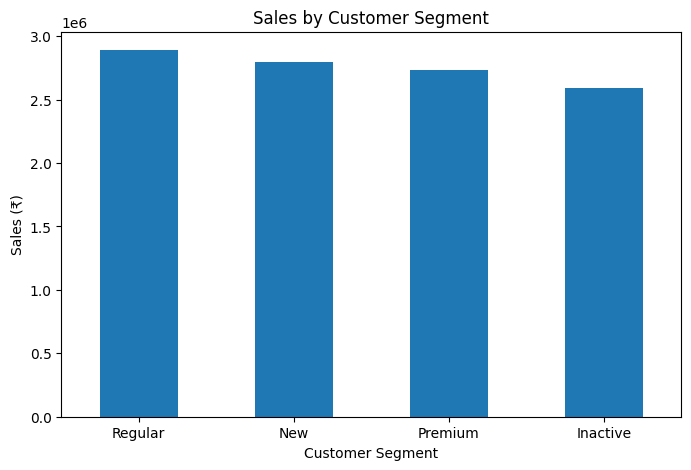

In [27]:
customer_segment_sales.plot(
    kind='bar',
    figsize=(8, 5),
    title='Sales by Customer Segment'
)

plt.xlabel('Customer Segment')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=0)
plt.show()

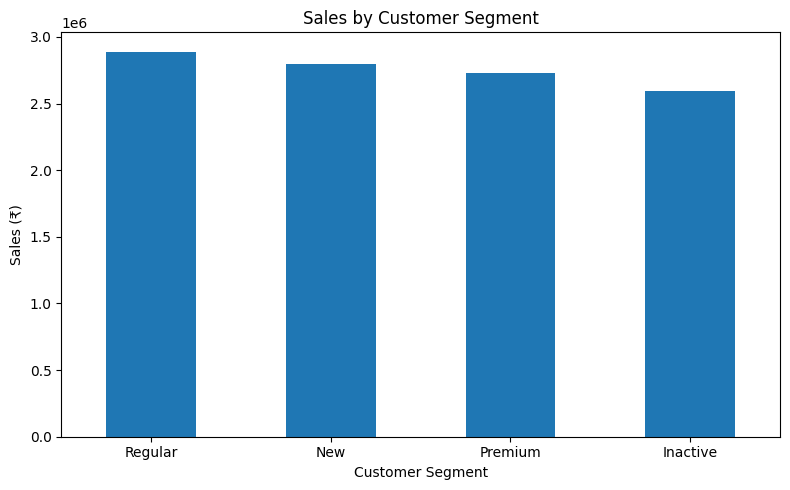

In [28]:
customer_segment_sales.plot(
    kind='bar',
    figsize=(8, 5),
    title='Sales by Customer Segment'
)

plt.xlabel('Customer Segment')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/sales_by_customer_segment.png",
    dpi=300
)

plt.show()

In [29]:
product_sales = combined_sales.groupby(
    'product_id'
)['item_sales'].sum().sort_values(ascending=False)

product_sales.head(10)

,item_sales
product_id,
51036,65212.70
34186,56464.65
880510,55182.94
557908,51830.35
264803,51790.96
739534,48733.44
18035,46509.12
883013,45534.48
349294,44868.00


In [31]:
products = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_products_analyzed.csv"
)

print("Products dataset loaded!")

Products dataset loaded!


In [32]:
top_products = product_sales.head(10).reset_index()

top_products = top_products.merge(
    products[['product_id', 'product_name', 'category', 'brand']],
    on='product_id',
    how='left'
)

top_products

,product_id,item_sales,product_name,category,brand
0,51036,65212.70,Baby Food,Baby Care,Karnik PLC
1,34186,56464.65,Mangoes,Fruits & Vegetables,Mandal-Kar
2,880510,55182.94,Bread,Dairy & Breakfast,Roy-Char
3,557908,51830.35,Vitamins,Pharmacy,Sundaram Inc
4,264803,51790.96,Vitamins,Pharmacy,Gole-Doshi
5,739534,48733.44,Toilet Cleaner,Household Care,"Gera, Narang and Karpe"
6,18035,46509.12,Dish Soap,Household Care,Ramesh Inc
7,883013,45534.48,Eggs,Dairy & Breakfast,Chahal Group
8,349294,44868.00,Onions,Fruits & Vegetables,Ganesan Ltd
9,112390,43899.00,Toothpaste,Personal Care,"Kibe, Contractor and Randhawa"


In [33]:
category_sales = combined_sales.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
).groupby('category')['item_sales'].sum().sort_values(ascending=False)

category_sales

,item_sales
category,
Dairy & Breakfast,639222.19
Pharmacy,592368.57
Fruits & Vegetables,559053.08
Pet Care,539888.75
Household Care,444244.25
Personal Care,394894.61
Snacks & Munchies,394648.71
Cold Drinks & Juices,392717.62
Grocery & Staples,359937.82


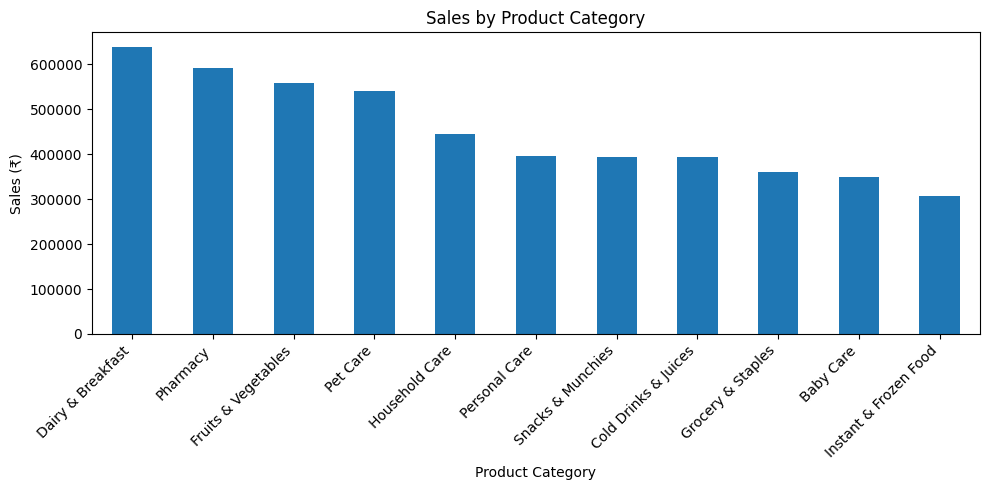

In [34]:
category_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Sales by Product Category'
)

plt.xlabel('Product Category')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/sales_by_product_category.png",
    dpi=300
)

plt.show()

In [35]:
delivery = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_delivery_performance_analyzed.csv"
)

print("Delivery dataset loaded!")

Delivery dataset loaded!


In [36]:
delivery['delivery_status'].value_counts()

,count
delivery_status,
On Time,3470
Slightly Delayed,1037
Significantly Delayed,493


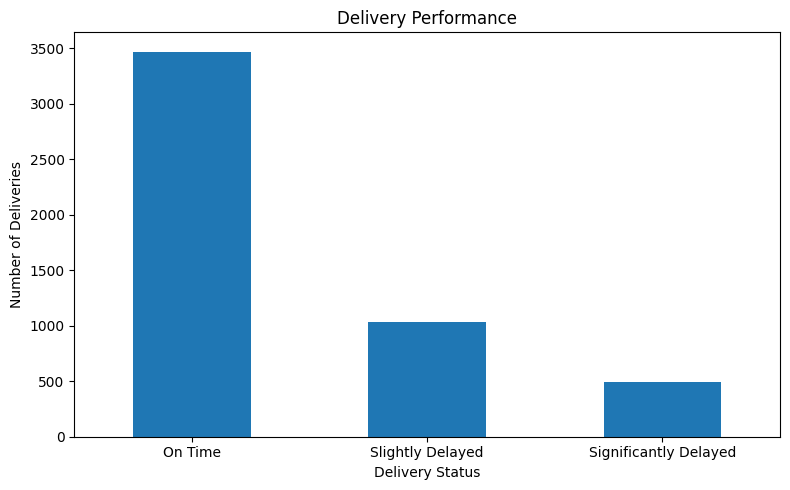

In [37]:
delivery_status = delivery['delivery_status'].value_counts()

delivery_status.plot(
    kind='bar',
    figsize=(8, 5),
    title='Delivery Performance'
)

plt.xlabel('Delivery Status')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/delivery_performance.png",
    dpi=300
)

plt.show()

In [38]:
delivery['delivery_time_minutes'].describe()

,delivery_time_minutes
count,5000.000000
mean,4.443000
std,8.063929
min,-5.000000
25%,-1.000000
50%,2.000000
75%,8.000000
max,30.000000


In [39]:
delivery_delay_by_status = delivery.groupby(
    'delivery_status'
)['delivery_time_minutes'].mean().sort_values()

delivery_delay_by_status

,delivery_time_minutes
delivery_status,
On Time,0.013833
Slightly Delayed,10.515911
Significantly Delayed,22.843813


In [40]:
delivery['reasons_if_delayed'].value_counts(dropna=False)

,count
reasons_if_delayed,
Traffic,3098
NaN,1902


In [41]:
delivery[delivery['delivery_status'] != 'On Time']['reasons_if_delayed'].value_counts(dropna=False)

,count
reasons_if_delayed,
Traffic,1530


In [42]:
delayed_percentage = (
    (delivery['delivery_status'] != 'On Time').mean() * 100
)

print(f"Delayed deliveries: {delayed_percentage:.2f}%")

Delayed deliveries: 30.60%


In [43]:
delivery.groupby(
    'delivery_status'
)['distance_km'].mean().sort_values()

,distance_km
delivery_status,
Significantly Delayed,2.692515
On Time,2.716441
Slightly Delayed,2.735564


In [44]:
marketing = pd.read_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/blinkit_marketing_performance_analyzed.csv"
)

print("Marketing dataset loaded!")

Marketing dataset loaded!


In [45]:
marketing_channel_roas = marketing.groupby(
    'channel'
)['roas'].mean().sort_values(ascending=False)

marketing_channel_roas

,roas
channel,
App,2.754301
Social Media,2.749188
Email,2.748861
SMS,2.710112


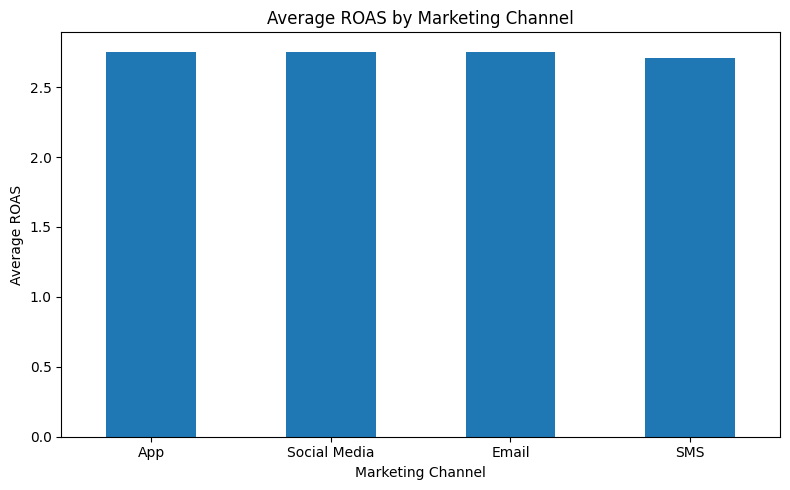

In [46]:
marketing_channel_roas.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average ROAS by Marketing Channel'
)

plt.xlabel('Marketing Channel')
plt.ylabel('Average ROAS')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/marketing_channel_roas.png",
    dpi=300
)

plt.show()

In [47]:
marketing_audience_roas = marketing.groupby(
    'target_audience'
)['roas'].mean().sort_values(ascending=False)

marketing_audience_roas

,roas
target_audience,
All,2.766572
New Users,2.753370
Premium,2.742103
Inactive,2.700802


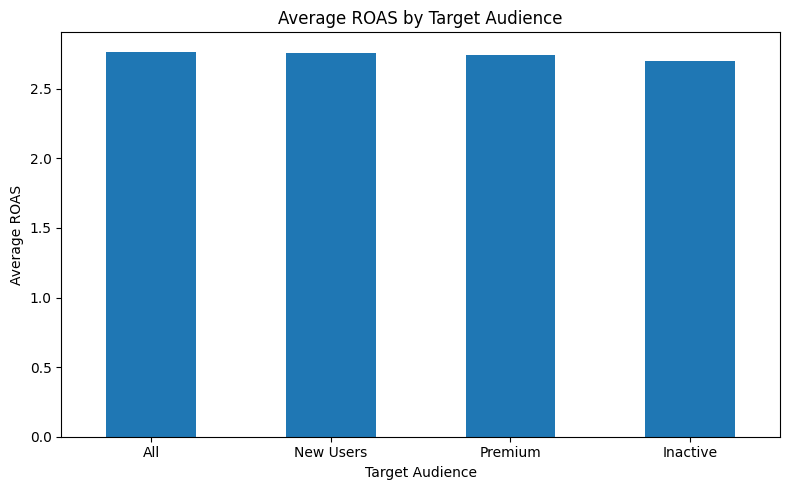

In [48]:
marketing_audience_roas.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average ROAS by Target Audience'
)

plt.xlabel('Target Audience')
plt.ylabel('Average ROAS')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/marketing_audience_roas.png",
    dpi=300
)

plt.show()

In [49]:
overall_metrics = {
    'Total Sales': combined_sales['order_total'].sum(),
    'Total Orders': combined_sales['order_id'].nunique(),
    'Total Customers': combined_sales['customer_id'].nunique(),
    'Average Order Value': combined_sales['order_total'].mean()
}

overall_metrics

{'Total Sales': np.float64(11009308.5),
 'Total Orders': 5000,
 'Total Customers': 2172,
 'Average Order Value': np.float64(2201.8617)}

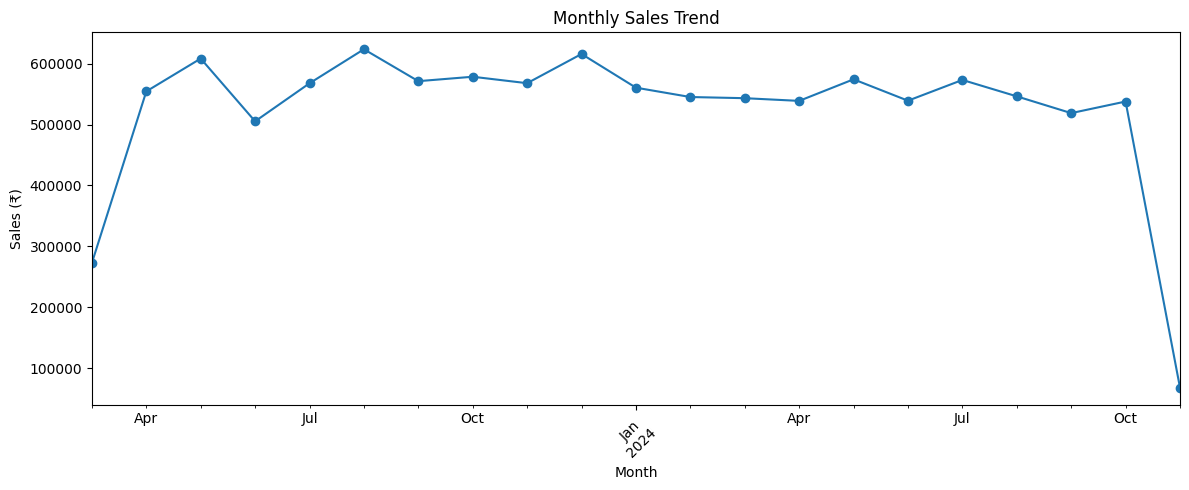

In [51]:
monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o',
    title='Monthly Sales Trend'
)

plt.xlabel('Month')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/monthly_sales_trend.png",
    dpi=300
)

plt.show()

In [52]:
payment_sales = combined_sales.groupby(
    'payment_method'
)['order_total'].sum().sort_values(ascending=False)

payment_sales

,order_total
payment_method,
Card,2865557.53
Cash,2770463.99
Wallet,2715004.27
UPI,2658282.71


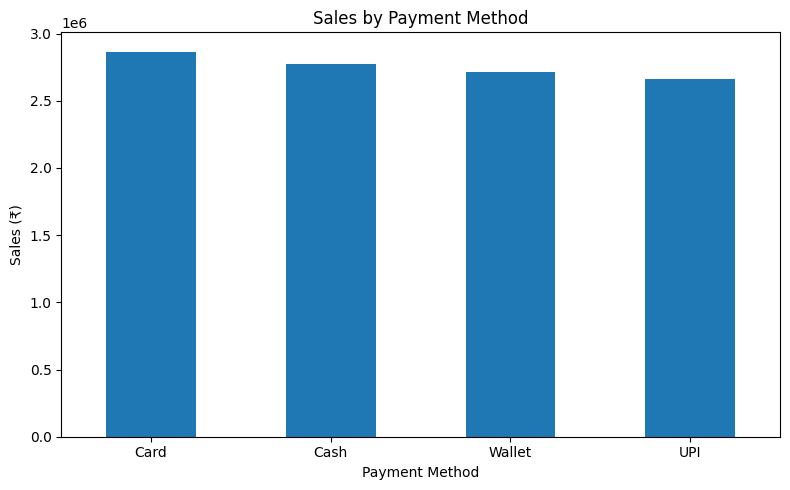

In [53]:
payment_sales.plot(
    kind='bar',
    figsize=(8, 5),
    title='Sales by Payment Method'
)

plt.xlabel('Payment Method')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/sales_by_payment_method.png",
    dpi=300
)

plt.show()

In [54]:
delivery_status_summary = delivery.groupby(
    'delivery_status'
)[['delivery_time_minutes', 'distance_km']].mean()

delivery_status_summary

,delivery_time_minutes,distance_km
delivery_status,,
On Time,0.013833,2.716441
Significantly Delayed,22.843813,2.692515
Slightly Delayed,10.515911,2.735564


In [55]:
delayed_reasons = delivery[
    delivery['delivery_status'] != 'On Time'
]['reasons_if_delayed'].value_counts()

delayed_reasons

,count
reasons_if_delayed,
Traffic,1530


In [56]:
overall_marketing = {
    'Total Marketing Spend': marketing['spend'].sum(),
    'Total Revenue Generated': marketing['revenue_generated'].sum(),
    'Overall ROAS': marketing['revenue_generated'].sum() / marketing['spend'].sum()
}

overall_marketing

{'Total Marketing Spend': np.float64(16319838.24),
 'Total Revenue Generated': np.float64(32193407.37),
 'Overall ROAS': np.float64(1.9726548080050088)}

In [57]:
marketing_summary = pd.DataFrame({
    'Metric': [
        'Total Marketing Spend',
        'Total Revenue Generated',
        'Overall ROAS'
    ],
    'Value': [
        marketing['spend'].sum(),
        marketing['revenue_generated'].sum(),
        marketing['revenue_generated'].sum() / marketing['spend'].sum()
    ]
})

marketing_summary

,Metric,Value
0,Total Marketing Spend,1.631984e+07
1,Total Revenue Generated,3.219341e+07
2,Overall ROAS,1.972655e+00


In [58]:
marketing_summary.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/marketing_summary.csv",
    index=False
)

print("Marketing summary saved to Google Drive!")

Marketing summary saved to Google Drive!


In [59]:
customer_insights = pd.DataFrame({
    'Customer Segment': customer_segment_sales.index,
    'Sales': customer_segment_sales.values,
    'Orders': customer_segment_orders.reindex(customer_segment_sales.index).values,
    'Average Order Value': customer_segment_aov.reindex(customer_segment_sales.index).values
})

customer_insights

,Customer Segment,Sales,Orders,Average Order Value
0,Regular,2890148.66,1320,2189.506561
1,New,2795854.48,1222,2287.933290
2,Premium,2731329.71,1268,2154.045513
3,Inactive,2591975.65,1190,2178.130798


In [60]:
customer_insights.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/customer_segment_insights.csv",
    index=False
)

print("Customer segment insights saved to Google Drive!")

Customer segment insights saved to Google Drive!


In [61]:
category_insights = pd.DataFrame({
    'Product Category': category_sales.index,
    'Sales': category_sales.values
})

category_insights

,Product Category,Sales
0,Dairy & Breakfast,639222.19
1,Pharmacy,592368.57
2,Fruits & Vegetables,559053.08
3,Pet Care,539888.75
4,Household Care,444244.25
5,Personal Care,394894.61
6,Snacks & Munchies,394648.71
7,Cold Drinks & Juices,392717.62
8,Grocery & Staples,359937.82
9,Baby Care,348227.18


In [62]:
category_insights.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/product_category_insights.csv",
    index=False
)

print("Product category insights saved to Google Drive!")

Product category insights saved to Google Drive!


In [63]:
delivery_insights = pd.DataFrame({
    'Delivery Status': delivery_status_summary.index,
    'Average Delay (Minutes)': delivery_status_summary['delivery_time_minutes'].values,
    'Average Distance (km)': delivery_status_summary['distance_km'].values
})

delivery_insights

,Delivery Status,Average Delay (Minutes),Average Distance (km)
0,On Time,0.013833,2.716441
1,Significantly Delayed,22.843813,2.692515
2,Slightly Delayed,10.515911,2.735564


In [64]:
delivery_insights.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/delivery_insights.csv",
    index=False
)

print("Delivery insights saved to Google Drive!")

Delivery insights saved to Google Drive!


In [65]:
marketing_insights = pd.DataFrame({
    'Marketing Channel': marketing_channel_roas.index,
    'Average ROAS': marketing_channel_roas.values
})

marketing_insights

,Marketing Channel,Average ROAS
0,App,2.754301
1,Social Media,2.749188
2,Email,2.748861
3,SMS,2.710112


In [66]:
marketing_insights.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/marketing_channel_insights.csv",
    index=False
)

print("Marketing channel insights saved to Google Drive!")

Marketing channel insights saved to Google Drive!


In [67]:
final_business_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Orders',
        'Total Customers',
        'Average Order Value',
        'Delayed Deliveries (%)',
        'Total Marketing Spend',
        'Marketing Revenue Generated',
        'Overall Marketing ROAS'
    ],
    'Value': [
        combined_sales['order_total'].sum(),
        combined_sales['order_id'].nunique(),
        combined_sales['customer_id'].nunique(),
        combined_sales['order_total'].mean(),
        (delivery['delivery_status'] != 'On Time').mean() * 100,
        marketing['spend'].sum(),
        marketing['revenue_generated'].sum(),
        marketing['revenue_generated'].sum() / marketing['spend'].sum()
    ]
})

final_business_summary

,Metric,Value
0,Total Sales,1.100931e+07
1,Total Orders,5.000000e+03
2,Total Customers,2.172000e+03
3,Average Order Value,2.201862e+03
4,Delayed Deliveries (%),3.060000e+01
5,Total Marketing Spend,1.631984e+07
6,Marketing Revenue Generated,3.219341e+07
7,Overall Marketing ROAS,1.972655e+00


In [68]:
final_business_summary.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/final_business_summary.csv",
    index=False
)

print("Final business summary saved to Google Drive!")

Final business summary saved to Google Drive!


In [69]:
final_insights = [
    "Regular customers generated the highest total sales among customer segments.",
    "New customers had the highest average order value.",
    "Dairy & Breakfast generated the highest sales among product categories.",
    "30.60% of deliveries were delayed.",
    "All delayed deliveries were associated with Traffic in the delay-reason field.",
    "The marketing dataset generated ₹3.22 crore in revenue from ₹1.63 crore of marketing spend, giving an overall ROAS of 1.97."
]

for i, insight in enumerate(final_insights, 1):
    print(f"{i}. {insight}")

1. Regular customers generated the highest total sales among customer segments.
2. New customers had the highest average order value.
3. Dairy & Breakfast generated the highest sales among product categories.
4. 30.60% of deliveries were delayed.
5. All delayed deliveries were associated with Traffic in the delay-reason field.
6. The marketing dataset generated ₹3.22 crore in revenue from ₹1.63 crore of marketing spend, giving an overall ROAS of 1.97.


In [70]:
final_insights_df = pd.DataFrame({
    'Insight': final_insights
})

final_insights_df.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/final_business_insights.csv",
    index=False
)

print("Final business insights saved to Google Drive!")

Final business insights saved to Google Drive!


In [71]:
recommendations = [
    "Focus on retaining Regular customers because they generated the highest total sales.",
    "Develop strategies to increase repeat purchases from New customers, who showed the highest average order value.",
    "Maintain strong inventory and availability for high-performing categories such as Dairy & Breakfast, Pharmacy, and Fruits & Vegetables.",
    "Investigate traffic-related delivery delays and explore operational measures to improve delivery reliability.",
    "Monitor marketing channel performance and optimize campaigns using ROAS and revenue generated as key performance indicators."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. Focus on retaining Regular customers because they generated the highest total sales.
2. Develop strategies to increase repeat purchases from New customers, who showed the highest average order value.
3. Maintain strong inventory and availability for high-performing categories such as Dairy & Breakfast, Pharmacy, and Fruits & Vegetables.
4. Investigate traffic-related delivery delays and explore operational measures to improve delivery reliability.
5. Monitor marketing channel performance and optimize campaigns using ROAS and revenue generated as key performance indicators.


In [72]:
recommendations_df = pd.DataFrame({
    'Recommendation': recommendations
})

recommendations_df.to_csv(
    "/content/drive/MyDrive/Blinkit_Business_Performance_Analysis/business_recommendations.csv",
    index=False
)

print("Business recommendations saved to Google Drive!")

Business recommendations saved to Google Drive!
